In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

In [4]:
x_train = x_train.reshape((len(x_train), 28*28))  # → (60000, 784)
x_test  = x_test.reshape((len(x_test), 28*28))   # → (10000, 784)

In [5]:
input_img = Input(shape=(784,))            # placeholder for flattened image
encoded = Dense(64, activation='relu')(input_img)   # compressed representation (latent)
decoded = Dense(784, activation='sigmoid')(encoded) # reconstruct flattened image
autoencoder = Model(input_img, decoded)   # full model: input -> decoded (reconstruction)

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                validation_data=(x_test, x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3470 - val_loss: 0.1602
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1505 - val_loss: 0.1251
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1219 - val_loss: 0.1077
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1061 - val_loss: 0.0970
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0961 - val_loss: 0.0898
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0896 - val_loss: 0.0849
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0851 - val_loss: 0.0816
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0817 - val_loss: 0.0791
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0794 - val_loss: 0.0774
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0780 - val_loss: 0.0763
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0768 - val_loss: 0.0755
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

In [9]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step


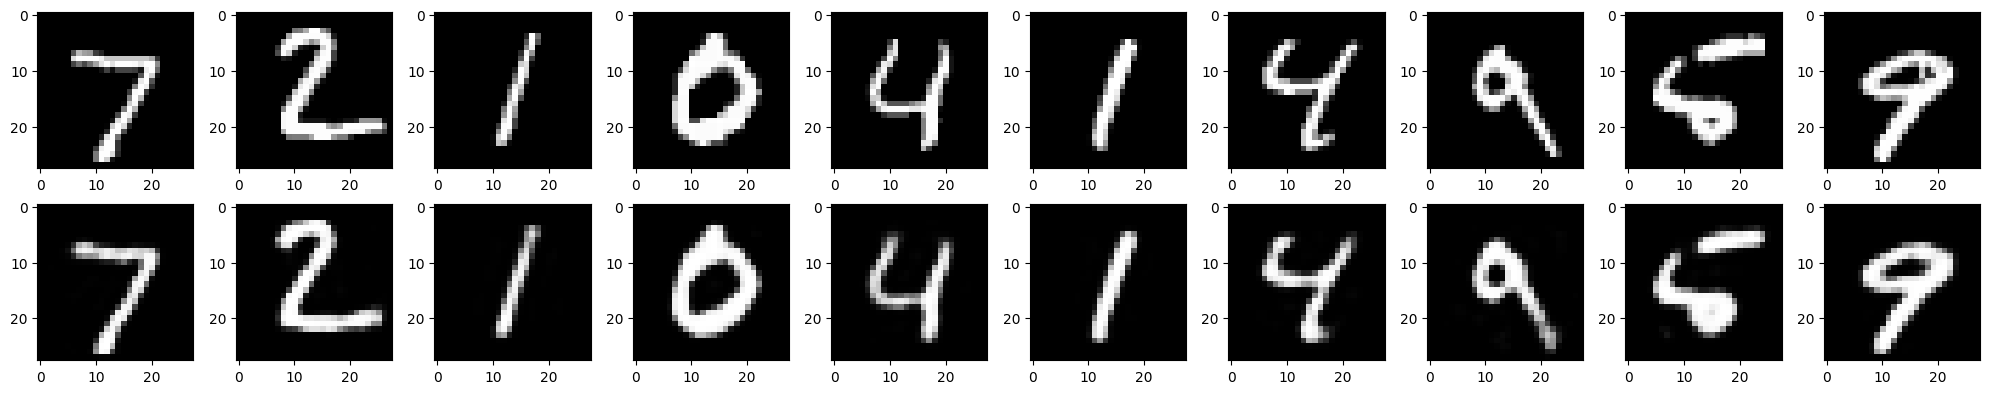

In [19]:
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')

plt.tight_layout()
plt.show()

In [14]:
encoder = Model(input_img, encoded)

In [15]:
sample = x_test[0].reshape(1, -1)  # shape (1, 784)

compressed = encoder.predict(sample)      # shape (1, 64)
print(compressed)

reconstructed = autoencoder.predict(sample)  # shape (1, 784)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[ 4.808577    7.70957     6.658737    5.443498    8.427688    1.4261035
   1.7434175   4.4398494  10.323458    2.6750903   5.0714393   5.2039766
   4.0848675   1.7785697   1.3084149   5.8714137   5.71065     0.44103178
   5.3712764   1.8815582   6.4027476   6.0052037   5.7395287   2.232105
   1.8551619   6.0228124   7.5430913   4.2018337   4.656742    8.516766
   1.8779578   7.76665     3.5120952   9.574319   10.644935    6.831555
   8.0570755   5.356135    5.846023    5.5772676   5.2963834   6.296342
   9.60407     5.101902    4.735285    3.1336637  12.401251    4.690889
   2.7806666   6.5726776   1.6377003   6.9695473   3.9970548   6.5884933
   4.26969     3.080912    3.764605    3.0257094   6.7904277   6.2342143
   5.3563643   1.2790596   2.9334364   3.4117618 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


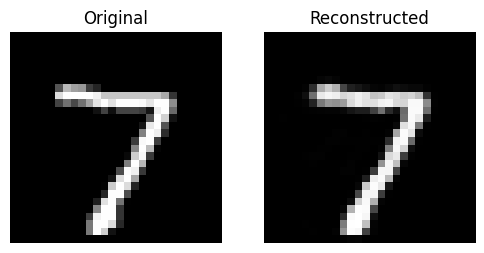

In [21]:
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(sample.reshape(28,28), cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(reconstructed.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()